[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/choROPeNt/FFTjax/blob/main/notebooks/lin-elastic_strain.ipynb)

# Two-Phase Composite RVE — Linear-Elastic Strain Solve

A minimal walkthrough of FFTjax's strain-based Newton-CG elastic solver
(`solvers.mechanical.strain_nw_cg.solve_elastic`) on a **two-phase composite**: a glass-fiber
reinforcement in an epoxy matrix, arranged in a square-packed pattern via
`generation.rve.make_square_composite_rve`, under a prescribed macroscopic strain.

We want to solve the mechanical equilibrium problem on this composite subject to its governing
PDE constraints:

$$
\nabla \cdot \sigma(\mathbf{x}) = 0, \qquad
\sigma = \mathbb{C}(\mathbf{x}):\varepsilon, \qquad
\varepsilon = \tfrac{1}{2}\big(\nabla u + \nabla u^\top\big)
$$

on a periodic domain, with the macroscopic average strain $\langle\varepsilon(\mathbf{x})\rangle_\Omega = \bar\varepsilon$
prescribed below.

The solver is the Krylov-based (CG-accelerated) Lippmann-Schwinger scheme: the periodic
Lippmann-Schwinger equation, discretized via trigonometric collocation and solved directly by
conjugate gradients against a fixed reference-medium Green's operator.

Because the two phases have a large stiffness contrast (~23x), the reference-medium correction is
nontrivial — the Newton-CG solve actually iterates, redistributing stress between the stiff fibers
and the compliant matrix. For the same reason we use Willot's `rotated` frequency scheme for the
Green's operator rather than the `standard` one: besides avoiding the 45° anisotropy bias of the
naive DFT discretization, it converges markedly better under high stiffness contrast.

## Setup

In [1]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print("Running on Colab — installing FFTjax...")
    %pip install -q git+https://github.com/choROPeNt/FFTjax.git
else:
    import sys
    sys.path.insert(0, "../src")
    print("Running locally — using the local src/ checkout.")

import os
import utils.precision  # side effect: configures JAX (X64 off on TPU, no GPU prealloc)
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

print("JAX backend:", jax.default_backend())
print("Devices:", jax.devices())
print("X64 enabled:", utils.precision.X64_ENABLED,
      "-> dtype:", jnp.zeros(1).dtype)

Running locally — using the local src/ checkout.
JAX backend: cpu
Devices: [CpuDevice(id=0)]
X64 enabled: True -> dtype: float64


## Generate the composite RVE

`generation.rve.make_square_composite_rve` builds a square-packed 2-fiber RVE: a matrix phase with
circular fiber cross-sections arranged on a square lattice, extruded along Z into a 3-D voxel grid. Here we use a 10-voxel-thick RVE, with a fiber volume fraction of 0.5, fiber radius of 5 μm, and voxel spacing of 0.2 μm.

Setting `nz=1` reduces the geometry to a 2-D-like slab (uniformly extruded along Z); combined with a macroscopic strain that has no out-of-plane (Z) components -- as prescribed below -- this gives a plane-strain solve.

In [2]:
from generation.rve import make_square_composite_rve

phase_np, N, n, L, phi_act = make_square_composite_rve(
    phi=0.5, r_fiber=0.005, spacing=0.0002, N_min=32, nz=10,
)
Nv = int(np.prod(n))

print("grid n :", n)
print("domain L [mm]:", tuple(f"{float(Li):.5g}" for Li in L))
print("fiber volume fraction (actual):", phi_act)

grid n : (89, 89, 10)
domain L [mm]: ('0.017725', '0.017725', '0.002')
fiber volume fraction (actual): 0.5010730968312082


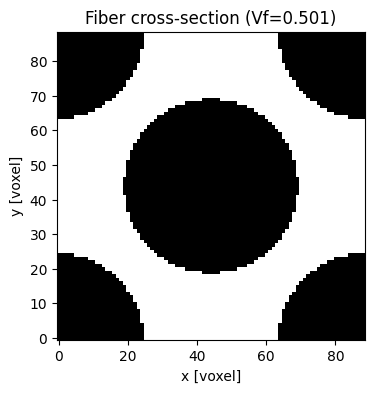

In [3]:
# Vizualize the fibre cross-section in the XY plane (Z=0)
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(phase_np[:, :, 0].T, origin="lower", cmap="gray_r")
ax.set_title(f"Fiber cross-section (Vf={phi_act:.3f})")
ax.set_xlabel("x [voxel]")
ax.set_ylabel("y [voxel]")
plt.show()

## Materials and stiffness field

A glass fiber in an epoxy matrix — a common, high-contrast (~23x stiffness ratio) composite.

In [4]:
from mat_models.elastic import LinearElasticIsotropic, assemble_C_field

matrix = LinearElasticIsotropic(E=3.0e3,  nu=0.35, name="epoxy matrix")
fiber  = LinearElasticIsotropic(E=70.0e3, nu=0.20, name="glass fiber")

phase = jnp.array(phase_np.reshape(-1))   # 0 = matrix, 1 = fibre
C_field = assemble_C_field([matrix, fiber], phase)

print(matrix)
print(fiber)

LinearElasticIsotropic (epoxy matrix): E=3e+03, nu=0.35, lam=2.59e+03, mu=1.11e+03
LinearElasticIsotropic (glass fiber): E=7e+04, nu=0.2, lam=1.94e+04, mu=2.92e+04


## Frequency grid, Green's operator, and solve

Step by step, matching the cell below:

1. **Voxel spacing and frequency grid.** `dx = L_mm / n` per axis, then
   `xi_flat = build_freq_grid(n, L_mm)` builds the angular-frequency grid
   $\xi = 2\pi k / L$ — one $(3,)$ wave-vector per voxel, reused for every FFT/iFFT pair below.

2. **Reference medium.** `lam0, mu0` — the average of the two phases' Lamé parameters
   $\mathbb{C}_0$, a reasonable choice when neither phase dominates.

3. **Green's operator.** `G_glob = build_green_operator(xi_flat, lam0, mu0, scheme="rotated", dx=dx)`
   evaluates $\hat\Gamma_0(\xi)$ at every frequency: a `(3, 3, 3, 3, Nv)` array, zero at $\xi=0$ by
   construction. `scheme="rotated"` uses Willot's effective frequencies instead of the raw DFT ones
   — removes the 45° anisotropy bias and converges better at this composite's stiffness contrast.

4. **Prescribed macroscopic strain.** `eps_bar` — a small in-plane shear $\bar\varepsilon_{12}=10^{-3}$,
   zero elsewhere.

5. **Solve.** `solve_elastic(n, C_field, G_glob, eps_bar, ...)` runs the Krylov (CG) solve. The
   periodic Lippmann-Schwinger equation for the total strain field is

$$
\varepsilon(x) + \Gamma_0 * \big[(\mathbb{C}(x)-\mathbb{C}_0):\varepsilon(x)\big] = \bar\varepsilon
$$

   which `solve_elastic` doesn't solve directly. Splitting $\varepsilon = \varepsilon_0 + \Delta\varepsilon$
   with $\varepsilon_0=\bar\varepsilon$ uniform, and using $\Gamma_0 * (\mathbb{C}_0:\Delta\varepsilon) = \Delta\varepsilon$
   for any zero-mean field plus $\hat\Gamma_0(0)=0$, the $\mathbb{C}_0$-dependence cancels exactly,
   leaving a linear system for the correction alone:

$$
\underbrace{\Gamma_0 * (\mathbb{C}:\Delta\varepsilon)}_{A(\Delta\varepsilon)}
\;=\;
\underbrace{-\,\Gamma_0 * (\mathbb{C}:\varepsilon_0)}_{b}
$$

   i.e. `A_op(v) = iFFT(G_glob : FFT(C_field : v))` against `bb = -iFFT(G_glob : FFT(C_field : eps0))`,
   solved by CG (`solvers._cg.cg_solve`) to give $\Delta\varepsilon$, then
   $\varepsilon = \varepsilon_0 + \Delta\varepsilon$ and $\sigma = \mathbb{C}:\varepsilon$.

6. **Results.** `converged`, the average shear stress $\bar\tau_{xy}$, and the resulting
   (composite, not either phase's) shear modulus $\bar\tau_{xy}/(2\bar\varepsilon_{xy})$.

In [5]:
from operators.green import build_freq_grid, build_green_operator
from solvers.mechanical.strain_nw_cg import solve_elastic

L_mm = tuple(float(Li) for Li in L)
dx = tuple(Li / ni for Li, ni in zip(L_mm, n))
xi_flat = build_freq_grid(n, L_mm)

lam0 = 0.5 * (matrix.lam + fiber.lam)
mu0  = 0.5 * (matrix.mu  + fiber.mu)
G_glob = build_green_operator(xi_flat, lam0, mu0, scheme="rotated", dx=dx)

# we apply a small shear strain in the XY plane, with zero normal strains
eps_bar = jnp.array([
    [0.0, 1.0e-3, 0.0],
    [1.0e-3, 0.0, 0.0],
    [0.0,    0.0, 0.0],
])

eps, sigma, delta, converged = solve_elastic(
    n, C_field, G_glob, eps_bar, toler_lin=1e-6, maxiter=1000,
)

print("converged     :", bool(converged))
print("tau_xy (avg) :", f"{float(jnp.mean(sigma[1, 0])):.3f}", "MPa")
print("G_xy (avg) :", f"{float(jnp.mean(sigma[1, 0]))/(2*float(jnp.mean(eps[1, 0]))):.3f}", "MPa")

converged     : True
tau_xy (avg) : 7.625 MPa
G_xy (avg) : 3812.685 MPa


The Newton-CG solve takes real iterations to converge — the correction field is doing real work redistributing stress between the stiff fibres and the compliant matrix.

## Post-processing

Now we can visualize the results and also export them as a `.xdmf`/`.h5` pair for further
post-processing in ParaView or other visualization software, via FFTjax's `IncrementalWriter`
(the project-wide standard for field-data output). Every field here -- displacement, strain,
stress, phase -- is evaluated on the same voxel grid, so all of them are written voxel-centered
(`Center="Cell"`); there's no FEM-style node/cell split in this spectral scheme, so there's nothing
to gain from writing displacement at a different resolution than everything else.

In [7]:
from post.fields import field_to_grid, von_mises, compute_displacement
from post.io import to_voigt

# Post-processing
# return the fields to a 3-D grid for visualization and export
eps_grid   = field_to_grid(eps, n)
sigma_grid = field_to_grid(sigma, n)
u_grid     = compute_displacement(eps, eps_bar, xi_flat, n, dx)
vm_grid    = von_mises(sigma_grid)

eps_voigt   = to_voigt(eps_grid).astype(np.float64)
sigma_voigt = to_voigt(sigma_grid).astype(np.float64)

display the stress and strain field in matplotlib.

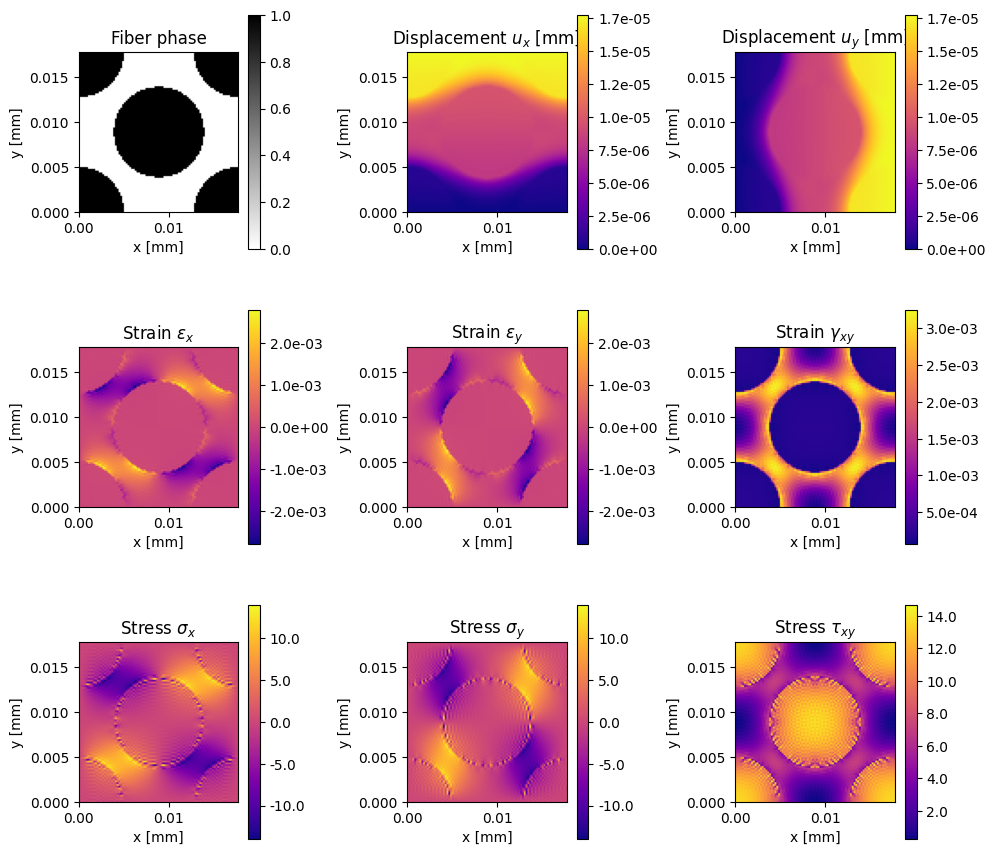

In [8]:
VOIGT_LABELS = ["x", "y", "z", "xy", "xz", "yz"]
extent = [0.0, n[0] * dx[0], 0.0, n[1] * dx[1]]  # physical [mm] extent, binned by voxel size dx

fig, axes = plt.subplots(3, 3, figsize=(10, 9))

im = axes[0, 0].imshow(phase_np[:, :, 0].T, origin="lower", cmap="gray_r", extent=extent)
axes[0, 0].set_title("Fiber phase")
fig.colorbar(im, ax=axes[0, 0])

im = axes[0, 1].imshow(u_grid[:, :, 0, 0].T, origin="lower", cmap="plasma", extent=extent)
axes[0, 1].set_title(r"Displacement $u_x$ [mm]")
fig.colorbar(im, ax=axes[0, 1], format="%.1e")

im = axes[0, 2].imshow(u_grid[:, :, 0, 1].T, origin="lower", cmap="plasma", extent=extent)
axes[0, 2].set_title(r"Displacement $u_y$ [mm]")
fig.colorbar(im, ax=axes[0, 2], format="%.1e")

for idx, i in enumerate([0, 1, 3]):
    eps_plot = eps_voigt[:, :, 0, i]
    label = rf"$\varepsilon_{{{VOIGT_LABELS[i]}}}$"
    if i == 3:  # shear component: report engineering shear strain gamma = 2*epsilon
        label = rf"$\gamma_{{{VOIGT_LABELS[i]}}}$"

    im = axes[1, idx].imshow(eps_plot.T, origin="lower", cmap="plasma", extent=extent)
    axes[1, idx].set_title(f"Strain {label}")
    fig.colorbar(im, ax=axes[1, idx], format="%.1e")

    label = rf"$\sigma_{{{VOIGT_LABELS[i]}}}$"
    if i == 3:
        label = rf"$\tau_{{{VOIGT_LABELS[i]}}}$"
    im = axes[2, idx].imshow(sigma_voigt[:, :, 0, i].T, origin="lower", cmap="plasma", extent=extent)
    axes[2, idx].set_title(f"Stress {label}")
    fig.colorbar(im, ax=axes[2, idx], format="%.1f")

for ax in axes.flat:
    ax.set_xlabel("x [mm]")
    ax.set_ylabel("y [mm]")

plt.tight_layout()
plt.show()

## Export the fields to XDMF/HDF5



In [10]:
from post.io import IncrementalWriter, to_voigt

output_dir = "../output"
os.makedirs(output_dir, exist_ok=True)

with IncrementalWriter(f"{output_dir}/composite_rve", grid_shape=n, grid_spacing=dx) as w:
    w.write_increment(1, {
        "phase":        phase_np.astype(np.float64),
        "displacement": u_grid.astype(np.float64),
        "strain":       to_voigt(eps_grid).astype(np.float64),
        "stress":       to_voigt(sigma_grid).astype(np.float64),
        "von_mises":    vm_grid.astype(np.float64),
    }, time=1.0)

print(f"Wrote {output_dir}/composite_rve.h5")
print(f"      {output_dir}/composite_rve.xdmf")
print("Open the .xdmf in ParaView with the 'Xdmf3ReaderT' reader.")

Wrote ../output/composite_rve.h5
      ../output/composite_rve.xdmf
Open the .xdmf in ParaView with the 'Xdmf3ReaderT' reader.


## Next steps

- Sweep grid size for the composite RVE above — the [Benchmark](https://choROPeNt.github.io/FFTjax/documentation/benchmark#linear-elastic-strain-solve) page does exactly this and times it.
- See [`lin-elastic_mixed-BC.ipynb`](./lin-elastic_mixed-BC.ipynb) for the same geometry/materials
  under a free-lateral-surface uniaxial-*stress* condition instead — a more realistic mechanical
  test, and a heterogeneous case where the strain-based mixed-BC solver
  (`solvers.mechanical.strain_nw_cg.dstrain_nw_cg_mixed`) isn't valid, so the displacement-based
  `ddisp_nw_cg` is used instead.